## Pneumonia Classification CNN

#### Birzeit University, Computer Scinnce Department
#### COMP4388: Machine Learning
#### Abdallah Aabed 1210802


### Introduction

In this project I'm using Convolutional Neural Networks to classify images into pre-defined categories. The task is to train a model that will detect if a chest x-ray image is diagnosed with Pneumonia or not.

### Background and theory

First of, let's simply understand the Pneumonia and existing solutions for it's classifications.

### Medical Defention, quick symptons and causes
**Pneumonia** is an inflammatory infection of the lungs' air sacs that causes them to fill with fluid or pus, resulting in symptoms ranging from a productive cough and chest pain to fever, chills, and difficulty breathing. It is primarily caused by infectious agents such as bacteria, viruses, and fungi, or by the accidental aspiration of food or liquids into the lungs. While many cases present as a severe flu-like illness, the condition can be life-threatening, particularly for infants, adults over 65, and those with weakened immune systems or chronic respiratory conditions. [1]

### Solutions in classification for Pneumonia

#### 1. Traditional Machine learning 
Like most of image classification problems, before deep learning, solutions have relied om Traditional Machine Learning solution. the reserach manually worked on feature engineering to specify the patterns in infected lungs like texture and shape, then they used the extracted features to feed to traditional ML algortihms like SVM and KNNs.

These solution are limited to capture the complex patterns in the images.

#### 2. CNN
After convultional neural networks CNNs there was no need to manually do the feature extractions. The development and design of CNN layers has allowed to use the pre-trained models and improve and result on high accuracy. However, this solution requires large datasets.

#### 3. Transformers

Transformers currently results in higher accuracy and it requires a high compuatioanl cost.

### Dataset:
- The dataset that used in this work is the Chest X-Ray dataset.downloaded through the row images of the dataset here Version (roboflow.com). https://universe.roboflow.com/mohamed-traore-2ekkp/chest-x-rays-qjmia/dataset/4
  
- Since the environment used to run this code is on kaggle, I have utilized the same dataset uploaded to kaggle: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia [1]

The dataset is organized into 3 folders (train, test, val) and contains subfolders for each image category (Pneumonia/Normal). 

There are 5,863 X-Ray images (JPEG) and 2 categories (Pneumonia/Normal). 


Here is an example from the dataset on how the Pneumonia actually looks like in the x-ray:


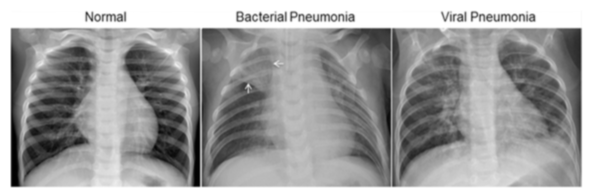


The Dataset original source is: https://data.mendeley.com/datasets/rscbjbr9sj/2

Under License: CC BY 4.0

Citation: http://www.cell.com/cell/fulltext/S0092-8674(18)30154-5

### Tools

For this project I have used Kaggle environemnt to utilze accelartors in Training, I have also used Tensorflow Keras along size CV, PIL for Image processing. 

## Important libaries for this project

To run this project the following is imported

In [1]:
import os
import random
import math
import numpy as np
import pandas as pd
import cv2
import PIL.Image as Image
import imagesize

import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

2026-01-27 18:15:21.379243: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769537721.561136      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769537721.613948      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769537722.042038      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769537722.042077      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1769537722.042080      24 computation_placer.cc:177] computation placer alr

#### loading the dataset into dataframe

The datset in Kaggle is splitted into three directories, However the Split percentage is low on Validation.

So I read the dataset for all folders in one Dataframe and do the split manually to 80:10:10

In [2]:
def load_dataset(base_path):
    """
    Takes the dataset path and return the pd.Dataframe
    """
    all_filepaths = []
    all_labels = []
    
    splits = ['train', 'test', 'val'] ## based on kaggle directories

    for split in splits:
        split_path = os.path.join(base_path, split)

        for folder in os.listdir(split_path):
            label_path = os.path.join(split_path, folder)
            
            if os.path.isdir(label_path):
                for image in os.listdir(label_path):
                    if image.lower().endswith(('.jpeg', '.jpg', '.png')): ## confirm the file is image
                        all_filepaths.append(os.path.join(label_path, image))
                        all_labels.append(folder)
    
    ## combine the DF
    df = pd.DataFrame({
        'ImagePath': all_filepaths,
        'Label': all_labels
    })

    return df

In [3]:
## Calling the function on Kaggle path to load the Dataframe
base_path = '/kaggle/input/chest-xray-pneumonia/chest_xray'
df = load_dataset(base_path)
df.head()

,ImagePath,Label
0,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
1,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
2,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
3,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
4,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA


#### split the dataset

The split rule used is:
- 80% for Training
- 10% for Validation
- 10% for testing

In [4]:
## Split to 80:10:10
## Standard random state is set, and ensuring the Labels are straified with the split for class imbalance
## also I have set the random state to ensur egetting the same results
train_df, rem_df = train_test_split(df, train_size=0.8, stratify=df['Label'], random_state=42)
val_df, test_df = train_test_split(rem_df, train_size=0.5, stratify=rem_df['Label'], random_state=42)

### reste the index after the split to use index locating later, starting from 0
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [5]:
print(f"Training Samples: {len(train_df)}")
print(f"Validation Samples: {len(val_df)}")
print(f"Testing Samples: {len(test_df)}")

Training Samples: 4684
Validation Samples: 586
Testing Samples: 586


#### Looking into samples

In this section we are looking into the datset attributes to make informed decisions on preprocessing.

In [6]:
train_df.sample(10)

,ImagePath,Label
3714,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL
3712,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL
3927,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL
2579,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
349,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
4380,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL
2071,/kaggle/input/chest-xray-pneumonia/chest_xray/...,NORMAL
3972,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
3759,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA
229,/kaggle/input/chest-xray-pneumonia/chest_xray/...,PNEUMONIA


#### Checking Labels

In [7]:
train_df['Label'].value_counts()

Label
PNEUMONIA    3418
NORMAL       1266
Name: count, dtype: int64

In [8]:
val_df['Label'].value_counts()

Label
PNEUMONIA    427
NORMAL       159
Name: count, dtype: int64

In [9]:
test_df['Label'].value_counts()

Label
PNEUMONIA    428
NORMAL       158
Name: count, dtype: int64

> We clearly have a class imbalance. As the "Normal" class is much smaller than  "Pneumonia" class in each dataset.

#### Checking Images

In [10]:
def show_random_samples(df, num):
    """
    Shows a random sample of images from the dataframe.
    """
    sample_df = df.sample(num)
    cols = 4
    rows = (num + cols - 1) // cols
    
    plt.figure(figsize=(20, rows * 5))
    
    for i, (idx, row) in enumerate(sample_df.iterrows()):
        plt.subplot(rows, cols, i + 1)
        img = Image.open(row['ImagePath'])
        plt.imshow(img, cmap='gray')
        plt.title(f"Diagnosis: {row['Label']}\n(Index: {idx})")
        plt.axis('off')
        
    plt.suptitle("Random Sample of the Dataset", fontsize=16)
    plt.show()

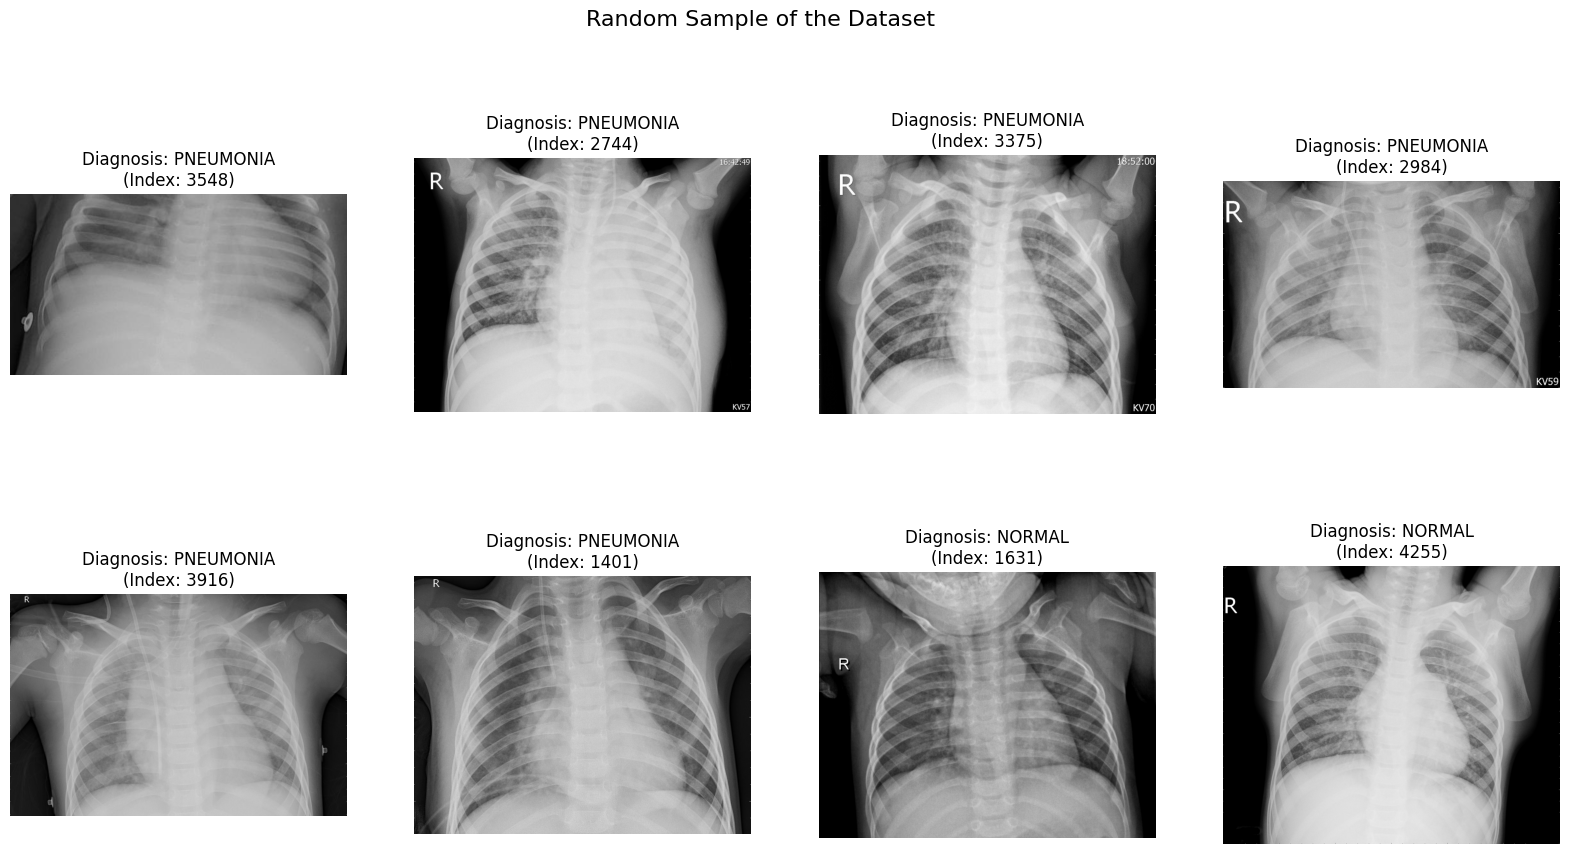

In [11]:
show_random_samples(train_df, 8)

> The samples clearly shows diffrent sizes of images and all of them are in grey scale 

- Let's take a look into each image attributes

Width: 1438, Height: 1140, Shape: (1438, 1140)


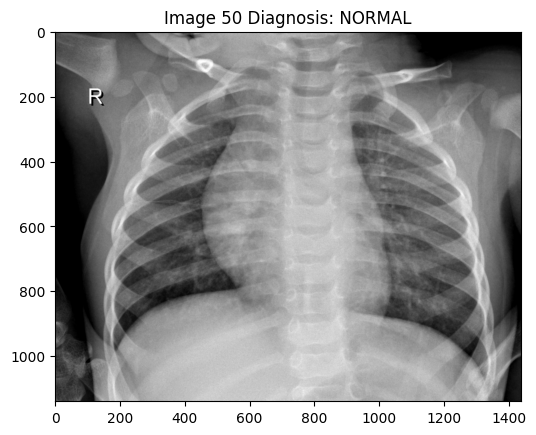

In [12]:
img = Image.open(train_df.loc[50, "ImagePath"])
plt.imshow(img, cmap='gray')
plt.title(f"Image 50 Diagnosis: {train_df.loc[50, 'Label']}")

print(f"Width: {img.width}, Height: {img.height}, Shape: {img.size}")

Width: 1320, Height: 976, Shape: (1320, 976)


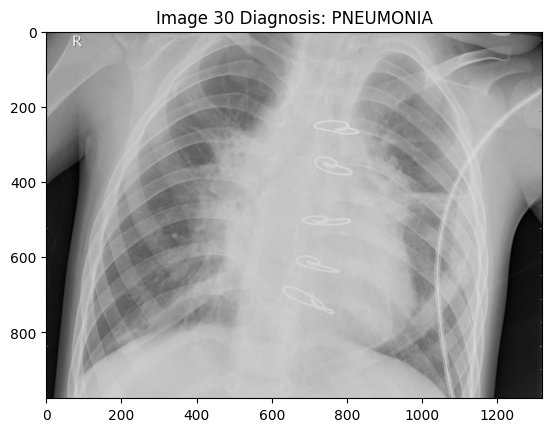

In [13]:
img = Image.open(train_df.loc[30, "ImagePath"])
plt.imshow(img, cmap='gray')
plt.title(f"Image 30 Diagnosis: {train_df.loc[30, 'Label']}")

print(f"Width: {img.width}, Height: {img.height}, Shape: {img.size}")

> The two samples shows diffrent sizes from each class, there is a clear diffrence in width

- Let's look at the distribution of the images sizes and ratios

In [14]:
def get_dims_fast(path):
    """
    Returns the 
    aspect_ratio, 
     and size of image
    """
    w, h = imagesize.get(path) ## using this libariy for faster computations
    return w/h, w*h

In [15]:
### calculated the dimensions and saved data into dataframe
dims_data = [get_dims_fast(path) for path in train_df['ImagePath']]
dims_df = pd.DataFrame(dims_data, columns=['aspect_ratio', 'area'])
dims_df.head()

,aspect_ratio,area
0,1.540230,746112
1,1.487179,579072
2,1.578005,964988
3,1.530106,1097712
4,1.398305,1246080


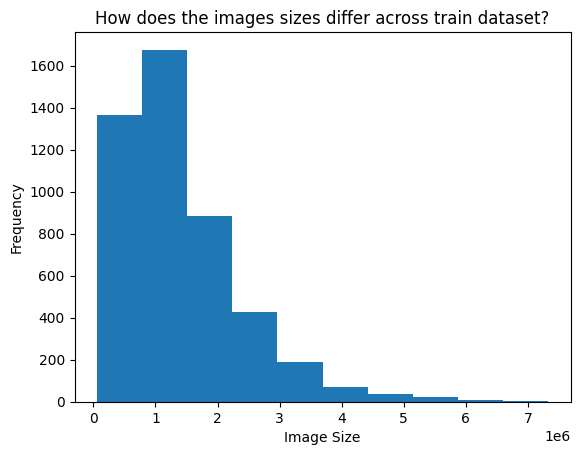

In [16]:
plt.hist(dims_df['area'], label="Image Size")
plt.title("How does the images sizes differ across train dataset?")
plt.xlabel("Image Size")
plt.ylabel("Frequency");

> Most images are quite large because of the nature of high reslotions for x ray datasets

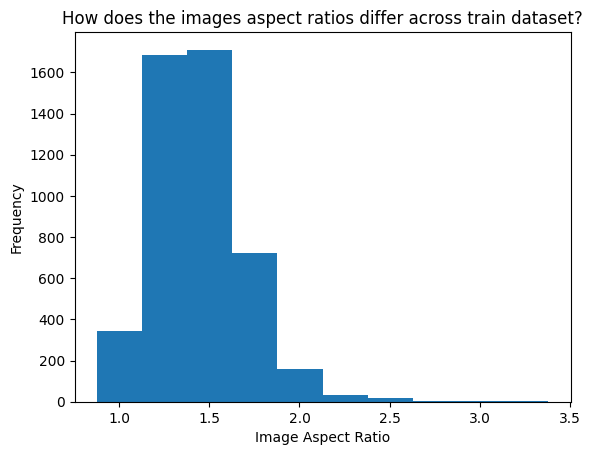

In [17]:
plt.hist(dims_df['aspect_ratio'], label="Image aspect ratio")
plt.title("How does the images aspect ratios differ across train dataset?")
plt.xlabel("Image Aspect Ratio")
plt.ylabel("Frequency");

> Most images are not square; they are roughly 1.3 to 1.6 (wider than they are tall).

---> Based on these data results, the following preprocessing will be done prior training

### Data Preprocessing

### Images preprocessing

- For image resize, I have tried the normal resizing which results in distortion and stretching in the aspect ratio, so then when I tested the model there was over fitting

- So I revisted Image preprocing to consider the image resize  with padding and keeping the aspect ratio.

  
- the IMG_SIZE is set to 224 which standard size for CNN tasks

- I have also applied Normaization

- and added the dimention for CNN

In [18]:
IMG_SIZE = 224

In [19]:
def resize_image_with_padding(path):
    """
    Takes the path image and resize keeping aspect ratio with centralized padding

    https://docs.opencv.org/4.x/d3/df2/tutorial_py_basic_ops.html 
    
    """
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None: return None

    # Calculate the scale and new dimensions
    h, w = img.shape[:2]
    scale = IMG_SIZE / max(h, w)
    new_w, new_h = int(w * scale), int(h * scale)
    img = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
    
    # Calculate padding for making image in centering
    delta_w = IMG_SIZE - new_w
    delta_h = IMG_SIZE - new_h
    top, bottom = delta_h // 2, delta_h - (delta_h // 2)
    left, right = delta_w // 2, delta_w - (delta_w // 2)
    
    img = cv2.copyMakeBorder(img, top, bottom, left, right, cv2.BORDER_CONSTANT, value=0)  # Apply padding (value=0 for black) for better results
    return img

In [20]:
def preprocess_image(path):
    """
    Returns preprocedd image for CNN
    - Resize with padding
    - Normalization
    - Add channel dimension
    """
    img = resize_image_with_padding(path)
    img = img / 255.0 ## Normalization to scales pixels to [0, 1]
    img = np.expand_dims(img, axis=-1) ### Add channel dimension for the CNN (Height, Width, 1)
    return img

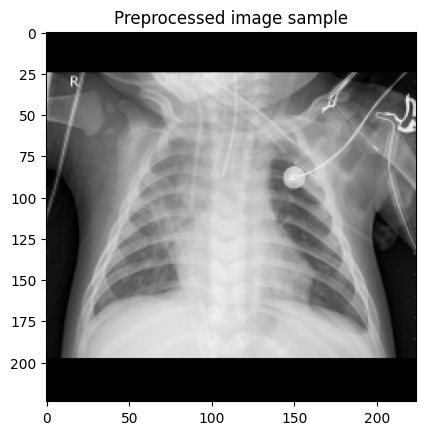

In [21]:
plt.imshow(preprocess_image(train_df.iloc[100]['ImagePath']), cmap="gray")
plt.title("Preprocessed image sample");

### Labels preprocsining

For labels pre processing I have transformed them using Binay encoding
- 0  NORMAL
- 1  PNEUMONIA

In [22]:
le = LabelEncoder() ## will be using the same encoder

### Preparing Datast

Perfom both image and label preprocessing on the sets

In [23]:
def prepare_dataset(df, encoder, is_training=True):
    """
    Preparing Dataset process both labels and images for a specific split.
    is_training (bool): If True, fits the encoder. If False, only transforms.
        
    Returns:
        X (np.array): Preprocessed image array.
        y (np.array): Encoded label array.
    """
    ## 1. Process Labels
    if is_training:
        df['Label_Num'] = encoder.fit_transform(df['Label'])
    else:
        df['Label_Num'] = encoder.transform(df['Label'])
    
    ## 2. Process Images
    preprocessed_images = []
    
    for i in range(len(df)):
        img_path = df['ImagePath'].iloc[i]
        image = preprocess_image(img_path) 
        preprocessed_images.append(image)
    
    X = np.array(preprocessed_images)
    y = np.array(df['Label_Num'])
    
    return X, y

In [24]:
## Prepare splits
X_train, y_train = prepare_dataset(train_df, le, is_training=True)
X_val, y_val     = prepare_dataset(val_df, le, is_training=False)
X_test, y_test   = prepare_dataset(test_df, le, is_training=False)

print(f" Train Set: {X_train.shape}") 
print(f" Validation set: {X_val.shape}") 
print(f" Test Set Shape: {X_test.shape}") 

 Train Set: (4684, 224, 224, 1)
 Validation set: (586, 224, 224, 1)
 Test Set Shape: (586, 224, 224, 1)


In [25]:
## print labels encodes
for i, label in enumerate(le.classes_):
    print(f"Encoded Value {i} == Label: {label}")

Encoded Value 0 == Label: NORMAL
Encoded Value 1 == Label: PNEUMONIA



### Classification task using deep learning CNN
- The main task is to Train a CNN model. 
- In this section two models architicure are trained 

#### Requested model (Model_A)

This model is required to do the training on, which is consist of the following layers, very basic and simple:

    - 1 convolutional layer (non-overlapping filters), 
    - 1 average pooling layer, 
    - fully connected NN.

In [26]:
def build_required_model(input_shape=(224, 224, 1)):
    """
    This function returns the required model architucture by the assignment
    """
    model = models.Sequential(name="Model_A")

    # 1. Convolutional Layer with non-overlapping filters
    model.add(layers.Conv2D(32, kernel_size=(4, 4), strides=(4, 4), activation='relu', input_shape=input_shape))

    # 2. Average Pooling Layer
    model.add(layers.AveragePooling2D(pool_size=(2, 2)))

    # 3. Fully Connected NN
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.5)) 
    
    # Output layer 
    model.add(layers.Dense(1, activation='sigmoid'))
    
    return model

In [27]:
model_a = build_required_model()

model_a.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1769537838.249733      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1769537838.253617      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "Model_A"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 56, 56, 32)     │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 28, 28, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,212,065 (12.25 MB)

 Trainable params: 3,212,065 (12.25 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
### compiling the model with the requird metrics
model_a.compile(optimizer='adam',
          loss='binary_crossentropy',
         metrics=['accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')])

### Training Model A

Dataset and Model A are ready for the training.
- The epochs are set to 25
- The batch size is set to 32

In [29]:
history_a = model_a.fit(np.array(X_train), y_train, 
                            validation_data=(np.array(X_val), y_val), 
                    epochs=25, batch_size=32)

Epoch 1/25


I0000 00:00:1769537844.265795      72 service.cc:152] XLA service 0x7ccd100051f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1769537844.265838      72 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1769537844.265845      72 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1769537844.583077      72 cuda_dnn.cc:529] Loaded cuDNN version 91002


 31/147 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7392 - loss: 0.5205 - precision: 0.8107 - recall: 0.8248

I0000 00:00:1769537846.671145      72 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


147/147 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.8140 - loss: 0.4131 - precision: 0.8561 - recall: 0.8949 - val_accuracy: 0.8942 - val_loss: 0.2603 - val_precision: 0.9011 - val_recall: 0.9602
Epoch 2/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8887 - loss: 0.2706 - precision: 0.9145 - recall: 0.9351 - val_accuracy: 0.9215 - val_loss: 0.2103 - val_precision: 0.9635 - val_recall: 0.9274
Epoch 3/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9084 - loss: 0.2180 - precision: 0.9343 - recall: 0.9403 - val_accuracy: 0.9283 - val_loss: 0.1750 - val_precision: 0.9425 - val_recall: 0.9602
Epoch 4/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9271 - loss: 0.1864 - precision: 0.9455 - recall: 0.9541 - val_accuracy: 0.9283 - val_loss: 0.1847 - val_precision: 0.9249 - val_recall: 0.9813
Epoch 5/25
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9317 - loss: 0.1799 - precision: 0.9468 - recall: 0.9594 - val_accuracy: 0.9437 - val_loss: 0.1582 - val

### Testing Model A

In [30]:
## saving and reconstrunting the model to test

model_a.save("model_a.keras")
reconstructed_model = load_model("model_a.keras")
reconstructed_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')])

test_loss_a, test_acc_a,test_recall_a, precision_a = reconstructed_model.evaluate(X_test, y_test)

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9492 - loss: 0.1823 - precision: 0.9427 - recall: 0.9907


In [31]:
### get predictions
y_pred_probs_a = reconstructed_model.predict(np.array(X_test))
y_pred_a = (y_pred_probs_a > 0.5).astype(int)  ## 0.5 as the standard threshold

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


#### Results of test for Model A:

In [32]:
report_a = classification_report(y_test, y_pred_a, target_names=le.classes_)
print(report_a)

              precision    recall  f1-score   support

      NORMAL       0.95      0.87      0.91       158
   PNEUMONIA       0.95      0.98      0.97       428

    accuracy                           0.95       586
   macro avg       0.95      0.93      0.94       586
weighted avg       0.95      0.95      0.95       586



#### Confusion matrix Model A

In [33]:
cm_a = confusion_matrix(y_test, y_pred_a)

tn, fp, fn, tp = cm_a.ravel()
print("False Positives > Healthy misidentified as Sick", fp)
print("False Negatives > Sick cases missed:", fn)

False Positives > Healthy misidentified as Sick 21
False Negatives > Sick cases missed: 7


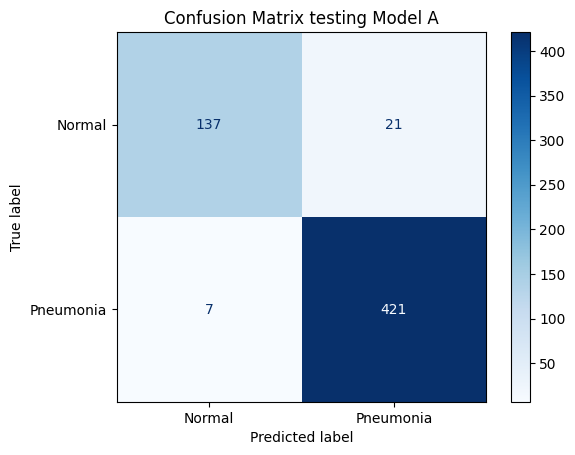

In [34]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_a, display_labels=['Normal', 'Pneumonia'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix testing Model A');

#### Requested model (Model_B)

This model is a proposed model to do the training on, which is consist of the following layers, more complex:


In [35]:
def build_proposed_model(input_shape=(224, 224, 1)):
    """
    Proposed model with integrated Data Augmentation for better generalization.
    """
    model = models.Sequential(name="Model_B")

    # --- Data Augmentation Block ---
    model.add(layers.Input(shape=input_shape))
    model.add(layers.RandomFlip("horizontal"))

    ## Layer 1
    model.add(layers.Conv2D(32, (3, 3), padding='same'))
    model.add(layers.BatchNormalization()) # Added for stability
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    ## Layer 2
    model.add(layers.Conv2D(64, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    ## Layer 3
    model.add(layers.Conv2D(128, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    ## Layer 4
    model.add(layers.Conv2D(256, (3, 3), padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    ## Fully Connected NN
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.4))

    # Output layer
    model.add(layers.Dense(1, activation='sigmoid'))

    return model

In [36]:
model_b = build_proposed_model()

model_b.summary()

Model: "Model_B"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 422,785 (1.61 MB)

 Trainable params: 421,825 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [37]:
### compiling the model with the requird metrics
model_b.compile(optimizer='adam',
          loss='binary_crossentropy',
         metrics=['accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')])

### Training Model B

For the second experiment
- The epochs are set to 50, more than the first model
- The batch size is set to 64, more than the first model
- I used a learning rate call back 

In [38]:
### learning rate is set to change base on Validation loss , if it's within 3 epochs does not change of by 0.3
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

In [39]:
history_b = model_b.fit(np.array(X_train), y_train, 
                            validation_data=(np.array(X_val), y_val), 
                    epochs=50, batch_size=64, callbacks=[lr_reducer])

Epoch 1/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 29s 220ms/step - accuracy: 0.8172 - loss: 0.3898 - precision: 0.8715 - recall: 0.8738 - val_accuracy: 0.7287 - val_loss: 0.6662 - val_precision: 0.7287 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 9s 125ms/step - accuracy: 0.9013 - loss: 0.2502 - precision: 0.9271 - recall: 0.9379 - val_accuracy: 0.7287 - val_loss: 0.6139 - val_precision: 0.7287 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 9s 125ms/step - accuracy: 0.9006 - loss: 0.2366 - precision: 0.9291 - recall: 0.9352 - val_accuracy: 0.5341 - val_loss: 0.6845 - val_precision: 0.7319 - val_recall: 0.5691 - learning_rate: 0.0010
Epoch 4/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 9s 126ms/step - accuracy: 0.9039 - loss: 0.2302 - precision: 0.9400 - recall: 0.9269 - val_accuracy: 0.7287 - val_loss: 0.5838 - val_precision: 0.7287 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 5/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 9s 127ms/step - accuracy:

### Tesing Model B

In [40]:
## saving and reconstrunting the model to test

model_b.save("model_b.keras")
reconstructed_model_b = load_model("model_b.keras")
reconstructed_model_b.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')])

test_loss_b, test_acc_b,test_recall_b, precision_b = reconstructed_model_b.evaluate(X_test, y_test)

19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.9607 - loss: 0.1122 - precision: 0.9623 - recall: 0.9846


In [41]:
### get predictions
y_pred_probs_b = reconstructed_model_b.predict(np.array(X_test))
y_pred_b = (y_pred_probs_b > 0.5).astype(int)  ## 0.5 as the standard threshold

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step


#### Results of test for Model B:

In [42]:
report_b = classification_report(y_test, y_pred_b, target_names=le.classes_)
print(report_b)

              precision    recall  f1-score   support

      NORMAL       0.95      0.92      0.94       158
   PNEUMONIA       0.97      0.98      0.98       428

    accuracy                           0.97       586
   macro avg       0.96      0.95      0.96       586
weighted avg       0.97      0.97      0.97       586



#### Confusion matrix Model B

In [43]:
cm_b = confusion_matrix(y_test, y_pred_b)

tn_b, fp_b, fn_b, tp_b = cm_b.ravel()
print("False Positives > Healthy misidentified as Sick", fp_b)
print("False Negatives > Sick cases missed:", fn_b)

False Positives > Healthy misidentified as Sick 12
False Negatives > Sick cases missed: 7


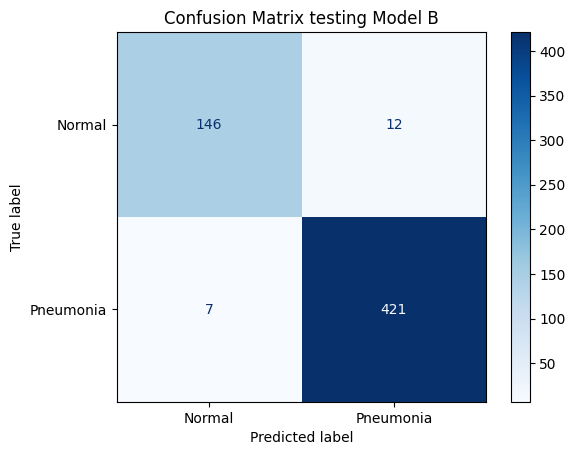

In [44]:
disp_b = ConfusionMatrixDisplay(confusion_matrix=cm_b, display_labels=['Normal', 'Pneumonia'])
disp_b.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix testing Model B');

### Models Comparisons

In this section, we look into comparing the models in terms of the following metrics:
- the Accuracy,
- Precision, 
- Recall,
- Loss 
- F1-Score of

In [45]:
def compare_model_metrics(hist_a, hist_b, metric_name):
    """
    omparison for a specific metric across two models
    """
    val_key = f'val_{metric_name}'
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    ## Model A 
    ax1.plot(range(1, len(hist_a.history[metric_name]) + 1), hist_a.history[metric_name], label='Train', markersize=3)
    ax1.plot(range(1, len(hist_a.history[val_key]) + 1), hist_a.history[val_key], label='Val', markersize=3)
    ax1.set_title(f'Model A {metric_name} 25 Epochs')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel(metric_name)
    ax1.legend()

    ## Model B 
    ax2.plot(range(1, len(hist_b.history[metric_name]) + 1), hist_b.history[metric_name], label='Train', markersize=3)
    ax2.plot(range(1, len(hist_b.history[val_key]) + 1), hist_b.history[val_key], label='Val', markersize=3)
    ax2.set_title(f'Model B: {metric_name} 50 Epochs')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel(metric_name)
    ax2.legend()

    plt.tight_layout()
    plt.show()

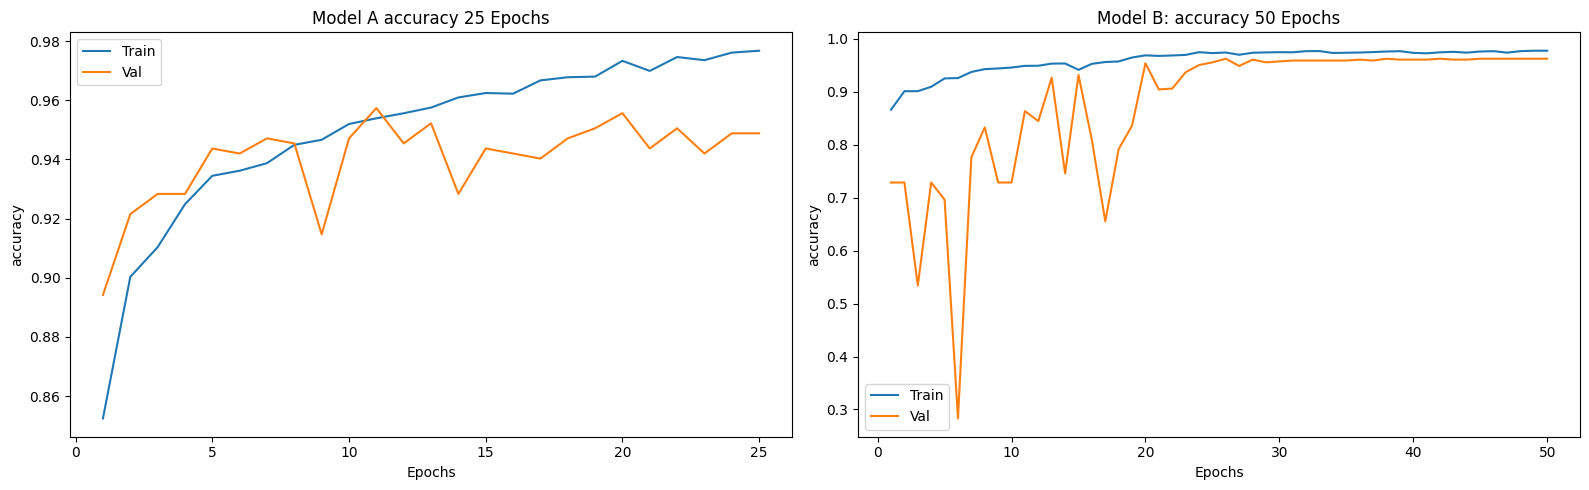

In [46]:
compare_model_metrics(history_a, history_b, 'accuracy')

> For the model A it shows the curve trend is going up, it starts low at first and at the end gets stable.

> For model B at the first 10 epochs the accuracy flactuates then get very smooth and stable.

> Model A has a good training accuracy but there is a slight gap that would be overfitting While in Model B the accuracy shows that the lines nearly touch.

> **Overl alll Model B results in a better trainnig results**

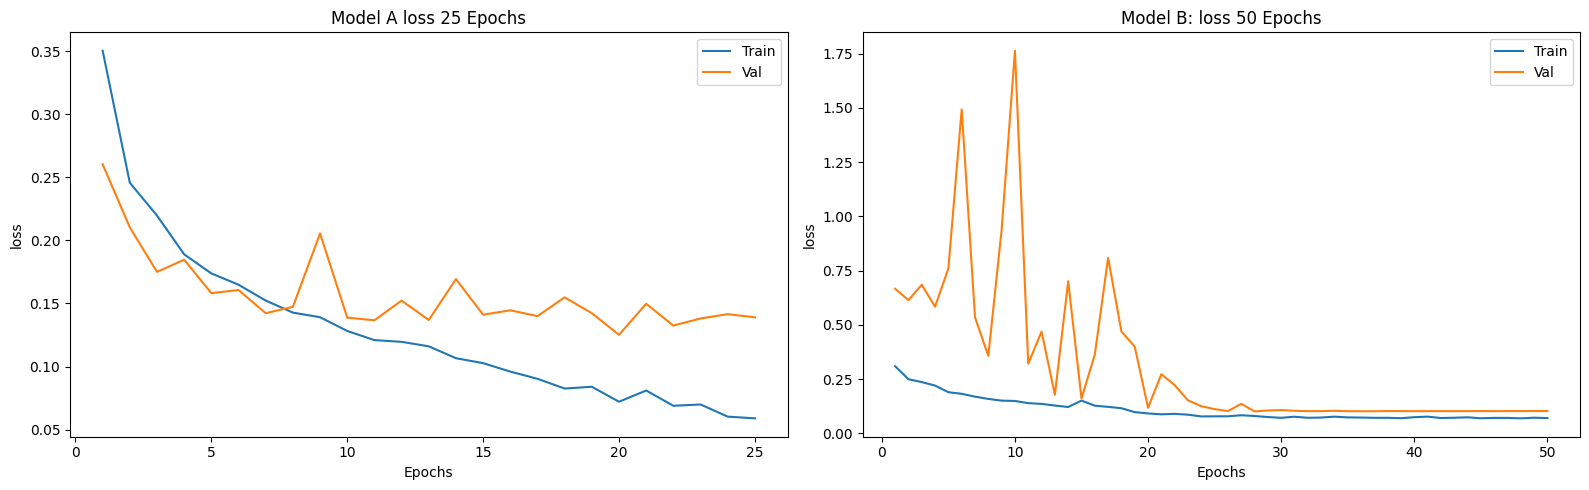

In [47]:
compare_model_metrics(history_a, history_b, 'loss')


> For model A it is noticed that for the final loss starts to get higher, while for Model B it gets lower and better

> For the model A curve of loss it's going down trend but its fluctaues through epoches, while for Model B it gets to a stable finish.

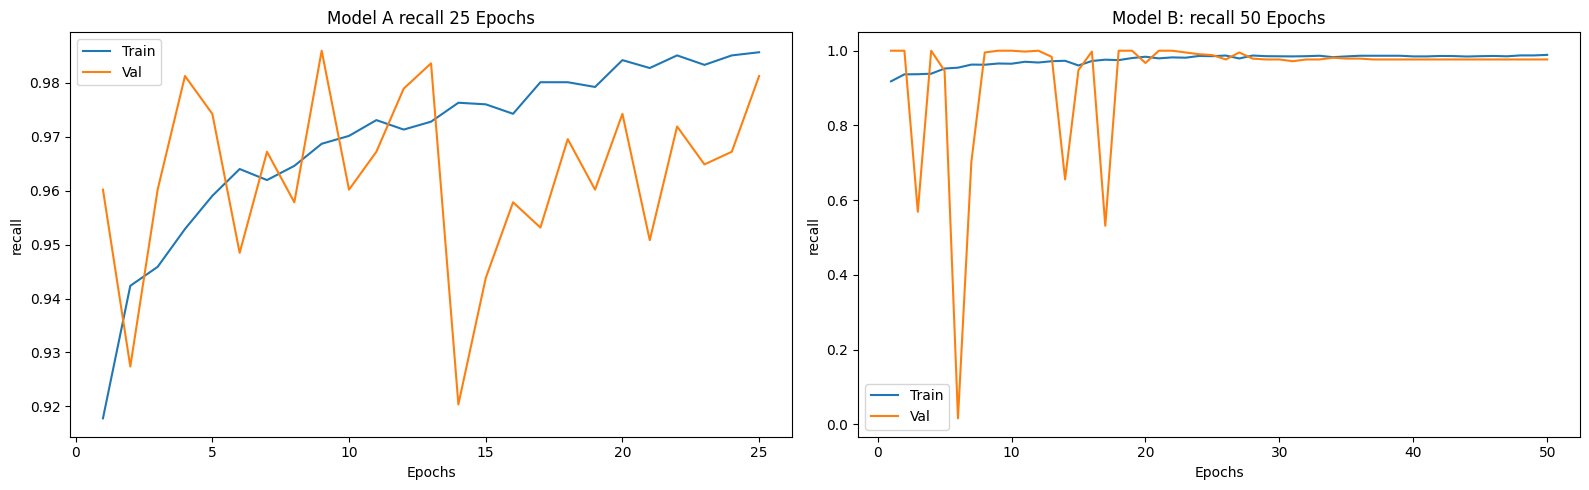

In [48]:
compare_model_metrics(history_a, history_b, 'recall')

> For the final recal it shows that it's higher in training than validation for Model A, while for model B it is consistenat and reach 0.97

> We can see that for model A the recall is very shaky thriugghout validation, while for model B it's shaky first 10 epochs then its smooth.

> Finally model A is risky, while model B is dependable after the first 10 epochs.

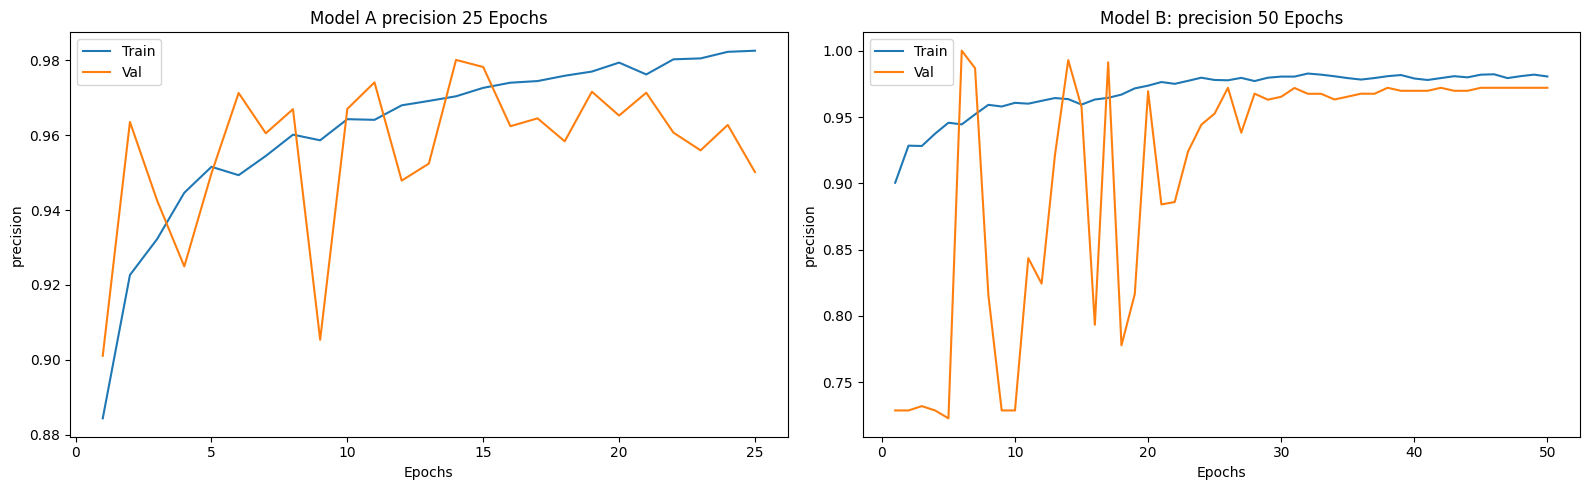

In [49]:
compare_model_metrics(history_a, history_b, 'precision')


> For the precison, the model A is high metric but incosisntet, while Model B is very high percison and stable.

> For model B it's excellent as the lines between validation and training alighns


### Discussions

When applying both Data Augmentaion and Learning rate schedule the results of the model is better, here is the final tetsing results:


| Metric              | Model A (25 Epochs)                 | Model B (50 Epochs)                   | Winner              |
|---------------------|-------------------------------------|---------------------------------------|---------------------|
| Accuracy            | 95%                                 | 95%                                   | Tie                 |
| Pneumonia Recall    | 0.97 (Identifies 97% of cases)       | 0.97 (Identifies 97% of cases)         | Tie                 |
| Normal Precision    | 0.93                                | 0.92                                   | Model A (Slightly)  |
| Training Stability  | Smooth but drifting                 | Volatile start, perfect finish         | Model B             |
| Generalization      | Risk of Overfitting                 | Stronger Reliability                  | Model B             |

## Refrences:
- [1] Dataset: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia 
- [2] https://www.mayoclinic.org/diseases-conditions/pneumonia/symptoms-causes/syc-20354204
- [3] https://docs.opencv.org/4.x/d3/df2/tutorial_py_basic_ops.html